# Plotting of angle-differential cross sections

This notebook showcases the plotting of a angle-differential cross section (dxs) extracted from an ENDF-6 file. To achieve this, we perform the following steps:

1) Load the necessary packages
2) Read the ENDF-6 file into a Python dictionary
3) Specify the reaction for which the dxs should be plotted
4) Specify two arrays with the incident energies and angle cosines (cosines of angle in radians) of interest
5) Invoke the function `compute_dxs` to extract a square (=two-dimensional array)
6) Plot it! :-)

For this example, we pick **beryllium-9** from the **ENDF/B-VIII.1** library and plot the angle-differential cross sections for **neutrons** produced in an **(n,2n)** reaction, both as 1d and 2d plot. In addition, some helpful functions for querying the reactions available in an ENDF file will be explained, too.

## Loading the necessary packages

First, we load **numpy** and **pandas** for convenient data manipulation and **pyplot** for plotting:

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# comment out %matplotlib directive for static plots
# widget option requires ipympl package
%matplotlib widget

The **EndfParserCpp** class will be used for loading the data from an ENDF-6 file into a Python dictionary:

In [2]:
from endf_parserpy import EndfParserCpp

**deg2rad** is a simple convenience function to convert degrees to radians. The function **get_reaction_string_for_mt** translates MT numbers to string representations of the nuclear reactions:

In [4]:
from endf_userpy.helpers import deg2rad
from endf_userpy.properties import get_reaction_string_for_mt

The following imported functions query information about reactions:

- **get_reactions** returns the reaction strings of available reactions
- **get_reaction_mts** retuns the MT numbers of available reactions
- **get_incident_energy_range** returns lower and upper limit of a reaction

In [5]:
from endf_userpy.properties import get_zap_for_particle
from endf_userpy.mf3_interpretation import (
    get_reactions,
    get_reaction_mts,
    get_incident_energy_range,
)

The **compute_xs** function retrieves the cross sections (in the laboratory system) of a reaction for a user-specified mesh of incident energies, adhering rigorously to the interpolation scheme specified in the ENDF file.

In [6]:
from endf_userpy.quantities import compute_xs

The **compute_dxs** function is the real champion of this notebook. It retrieves the angle-differential cross section in the laboratory system associated with an ejectile from a nuclear reaction. The user specifies a cartesian mesh defined by two 1d meshes of incident energies and and angle cosines (**mu**), respectively. All of these quantities refer to the laboratory system.

This function performs all the required 1-dim and 2-dim interpolations, reconstructs the dxs distribution from Legendre polynomials, and converts the result into the laboratory system.

In [7]:
from endf_userpy.quantities import compute_dxs

## Loading the ENDF data

We use the functionality of the **endf-parserpy** package to load the data from the ENDF file into a Python dictionary:

In [8]:
endf_file = os.path.join('..', 'tests', 'data', 'n-004_Be_009.endf')
parser = EndfParserCpp()
endf_dict = parser.parsefile(endf_file)

To get an idea about the ENDF file, we create a pandas DataFrame that shows the available reactions and their associated MT numbers:

In [9]:
reacs = get_reactions(endf_dict)
reac_mts = get_reaction_mts(endf_dict)
reac_dt = pd.DataFrame({'reaction': reacs, 'mt': reac_mts}).set_index('mt')
reac_dt

,reaction
mt,
1,"(n,total)"
2,"(n,n_0)"
3,"(n,nonelas)"
16,"(n,2n)"
102,"(n,g)"
103,"(n,p)"
104,"(n,d)"
105,"(n,t)"
107,"(n,a)"


In this notebook, we want to plot the angle-differential cross section for neutrons produced by the **(n,2n)** reaction. To get an idea about the viable incident energy range of this reaction, let's compute the total **(n,2n)** cross section on a dense mesh of inident energies first. The **get_energy_range** function is helpful in this regard to obtain the lower and upper limit of the reaction.

In [10]:
mt = 2
energy_range = get_incident_energy_range(endf_dict, mt)
energies = np.linspace(energy_range[0], energy_range[1], 1000) 
xs = compute_xs(endf_dict, mt, energies)

Let's plot the cross section. For convenience, we'll use **MeV** and **mbarn** for plotting.

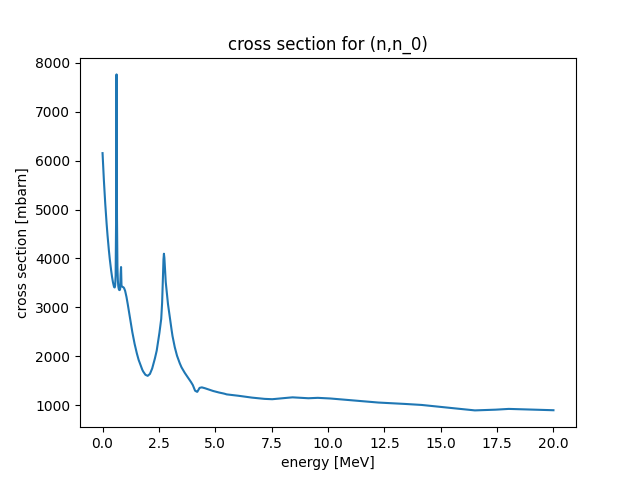

In [11]:
plt.plot(energies / 1e6, xs * 1e3)
plt.title(f'cross section for {reac_dt.at[mt, "reaction"]}')
plt.xlabel('energy [MeV]')
plt.ylabel('cross section [mbarn]')
plt.show()

## Plotting the angle-differential cross section

For plotting the angle-differential cross section of a reaction, it is a good idea to see for which reaction angular distributions are available. To this end, we list the available MT numbers given in **MF4**.

In [12]:
ang_mts = list(endf_dict[4].keys())
print(', '.join((f'MT: {m}' for m in ang_mts)))

MT: 2


Checking the DataFrame with associations of reactions with MT numbers above, we see that an angle-differential distribution for elastic scattering **(n, n_0)** is available.

Now we specify a 2-dim mesh that is the cartesian product of the 1-dim meshes for incident energy and angle-cosines. In this notebook, we'll use an incident energy mesh that covers an interesting energy range in the cross section plot above (0.1 to 1 MeV). The mesh of angle cosines covers the range from -1 to 1 degree (corresponding to 180 and 0 degree, respectively).

In [13]:
zap = get_zap_for_particle('n')
energies_in = np.linspace(0.1e6, 1e6, 1000)
angle_cosines_out = np.linspace(-1, 1, 1000)

With these specifications of the 1d meshes, we can invoke **compute_dxs** to obtain a two-dimensional array (a square) with all the angle-differential cross section values.

In [14]:
dx_values = compute_dxs(endf_dict, mt, zap, energies_in, angle_cosines_out)

By now, everything is ready for a nice 3d plot of the angle-differential cross section. The **np.meshgrid** function produces the cartesian product mesh required by **plot_surface**.

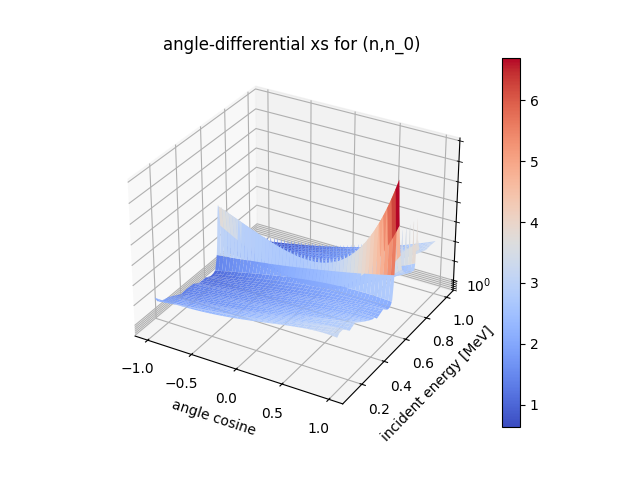

In [15]:
Z_values = dx_values[:,:]
X, Y = np.meshgrid(angle_cosines_out, energies_in / 1e6) 
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(X, Y, Z_values, cmap='coolwarm', edgecolor='none')
ax.set_zscale('log')
fig.colorbar(surf)
plt.title(f'angle-differential xs for {reac_dt.at[mt, "reaction"]}')
plt.ylabel('incident energy [MeV]')
plt.xlabel('angle cosine')
plt.show()

As beautiful as this 3d plot looks, it is difficult to interpret it quantitatively. Therefore, let's compute another dxs value cube where we only supply a single incident energy. Because we know by construction that this quare is of dimension 1 x 10000, we immediately flatten the result to a 1-dim numpy array.

In [16]:
cur_einc = 6.5e5
angle_cosines_out = np.linspace(-1, 1, 1000)
dxvals = compute_dxs(
    endf_dict, mt, zap, np.array([cur_einc]), angle_cosines_out
).flatten()

Plotting this data, we see in better detail how the slice at incident energy at 650 keV in the three-dimensional plot above evolves as a function of emitted energy.

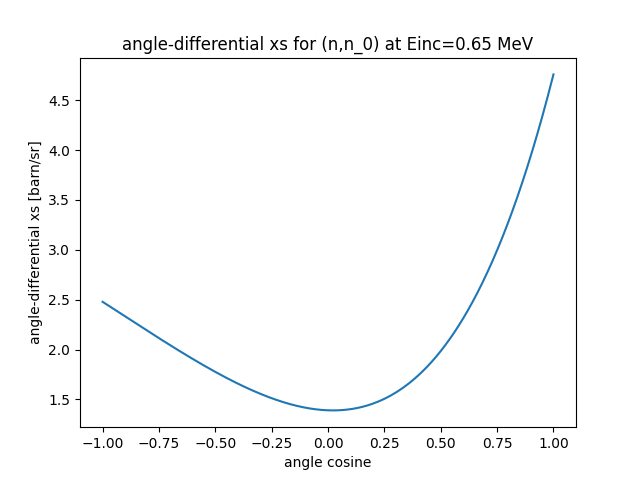

In [17]:
plt.figure()
plt.plot(angle_cosines_out, dxvals)
plt.title(f'angle-differential xs for {reac_dt.at[mt, "reaction"]} at Einc={cur_einc/1e6} MeV')
plt.xlabel('angle cosine')
plt.ylabel('angle-differential xs [barn/sr]')
plt.show()

## Summary

This notebook demonstrated how angle-differential cross sections can be computed using the **compute_dxs** function. The user passes two one-dimensional arrays for the incident energy and angle cosine (all in the lab-system) to the function and obtains a two-dimensional array (a square) with the resulting dxs values (also in the lab-system). Importantly, even though dxs data can be stored in [various representations][1] in an ENDF-6 file, a user doesn't need to concerned with these details anymore.


[1]: https://www.nndc.bnl.gov/endfdocs/ENDF-102-2023.pdf#page=131